# V42: LQ45 AI Strategy - Trend Override (Hybrid) vs Static

**Analysis of V41**: The previous strategy failed because the AI stayed in Cash (Risk-Off) during the strong market rally in Q3-Q4 2025. The AI model was overly pessimistic (False Negative).

### Modification (Hybrid Logic):
We introduce a **Trend-Following Override** to prevent the AI from exiting too early during a bull run.

**New Logic:**
- **Risk-On Condition (Stay Invested)**:
  - IF (AI Prob >= 0.60)  **OR**  (Market Price > MA50).
- **Risk-Off Condition (Cash)**:
  - IF (AI Prob < 0.60) **AND** (Market Price < MA50).

**Rationale**:
- If the AI is scared but the market trend is technically strong (Price > MA50), we trust the trend and stay invested.
- We only retreat to Cash if **BOTH** the AI predicts danger **AND** the technical trend is broken (Price < MA50).

### Comparisons:
1. **AI Hybrid (Trend Override)**: AI + MA50 Filter + Markowitz.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [10]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Calculate Trend Signal for Override (Price > MA50)
trend_bullish = (market_price > ma50).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

opt_t = 0.60
print(f"[Strategy] Using Base Threshold: {opt_t:.2f} with MA50 Override")

[Strategy] Using Base Threshold: 0.60 with MA50 Override


In [11]:
# --- 3. Simulation Logic (Hybrid) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_hybrid(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    state_history = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        current_state = "Neutral"
        weights = {}

        if strategy_type == 'AI Hybrid':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            
            # HYBRID LOGIC:
            # Go to Cash ONLY if AI is scared (< T) AND Trend is Down (< MA50).
            # If Trend is UP, stay invested regardless of AI.
            is_risk_off = (prob < threshold) and (not is_trend_up)
            
            if is_risk_off: 
                weights = {'CASH': 1.0}
                current_state = "Cash (AI+Trend)"
            else:
                # Risk On: Markowitz on all assets (No Graph Filter)
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                current_state = "Invested (Trend/AI)"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)

Running AI Hybrid Strategy (T=0.60 + MA50 Override)...
Running Markowitz Static...
Calculating IHSG Benchmark...


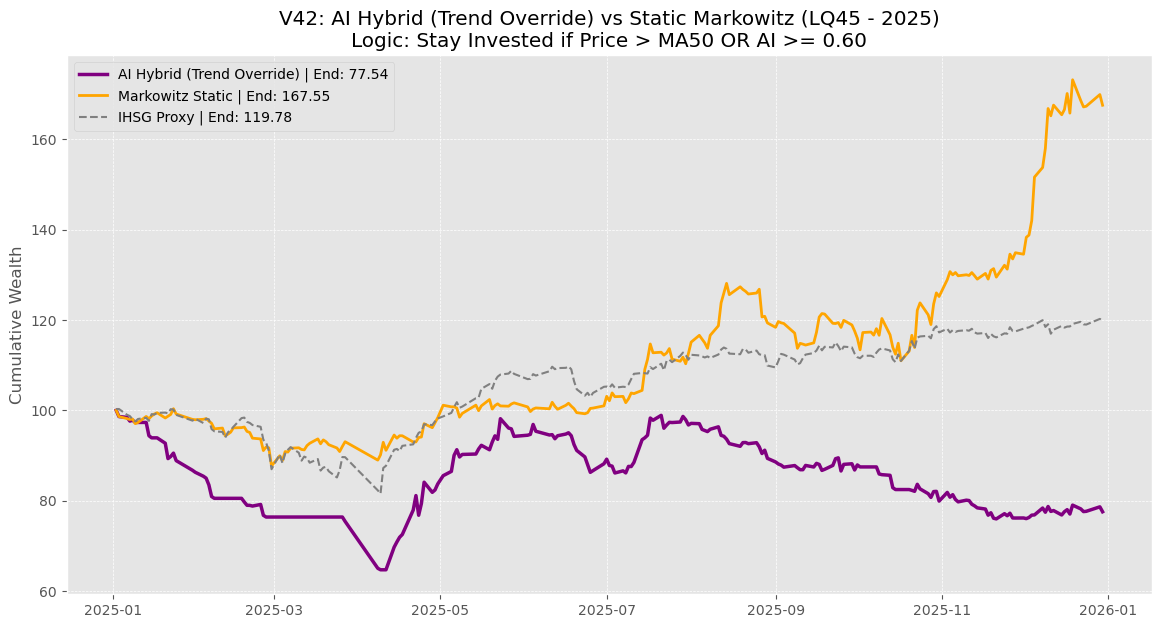


--- Performance Summary ---
AI Hybrid (Trend Override): 77.54
Markowitz Static          : 167.55
IHSG Benchmark            : 119.78

AI Activity: Invested 185 days, Cash 51 days


In [12]:
# --- 4. Execution & Visualization ---

test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
test_trend = trend_bullish.loc[test_dates]

print("Running AI Hybrid Strategy (T=0.60 + MA50 Override)...")
ai_res = run_simulation_hybrid('AI Hybrid', test_dates, returns, ai_probs=test_probs, trend_signal=test_trend, threshold=opt_t)

print("Running Markowitz Static...")
static_res = run_simulation_hybrid('Markowitz Static', test_dates, returns)

print("Calculating IHSG Benchmark...")
benchmark_val = 100 * (1 + market_return.loc[test_dates]).cumprod()

# Calculate Stats
ai_final = ai_res['Portfolio_Value'].iloc[-1]
stat_final = static_res['Portfolio_Value'].iloc[-1]
bench_final = benchmark_val.iloc[-1]

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(ai_res.index, ai_res['Portfolio_Value'], label=f'AI Hybrid (Trend Override) | End: {ai_final:.2f}', linewidth=2.5, color='purple')
plt.plot(static_res.index, static_res['Portfolio_Value'], label=f'Markowitz Static | End: {stat_final:.2f}', linewidth=2, color='orange')
plt.plot(benchmark_val.index, benchmark_val, label=f'IHSG Proxy | End: {bench_final:.2f}', linestyle='--', color='gray')

plt.title(f'V42: AI Hybrid (Trend Override) vs Static Markowitz (LQ45 - 2025)\nLogic: Stay Invested if Price > MA50 OR AI >= {opt_t:.2f}')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n--- Performance Summary ---")
print(f"AI Hybrid (Trend Override): {ai_final:.2f}")
print(f"Markowitz Static          : {stat_final:.2f}")
print(f"IHSG Benchmark            : {bench_final:.2f}")

# Analyze Activity
days_invested = ai_res[ai_res['State'].str.contains('Invested')].shape[0]
days_cash = ai_res[ai_res['State'].str.contains('Cash')].shape[0]
print(f"\nAI Activity: Invested {days_invested} days, Cash {days_cash} days")